# Display Sample Predictions
## ICT3212 - Introduction to Intelligent Systems
### Facial Emotion Detection System (Inflators)

This notebook loads the trained CNN model and displays sample predictions on test images, showing:
1. Predicted emotion label vs actual (true) label.
2. Confidence scores for each prediction.
3. Correct vs incorrect predictions highlighted.
4. Prediction summary and accuracy on samples.

---
## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow Version: {tf.__version__}')
print('All libraries imported successfully!')

TensorFlow Version: 2.20.0
All libraries imported successfully!


---
## 2. Load and Preprocess Data

In [2]:
# Load FER-2013 dataset
CSV_PATH = 'data/fer2013.csv'
df = pd.read_csv(CSV_PATH)

# Emotion labels
EMOTION_LABELS = {0: 'Angry', 1: 'Fear', 2: 'Happy', 3: 'Sad', 4: 'Surprise', 5: 'Neutral'}
EMOTION_EMOJIS = {0: '😠', 1: '😨', 2: '😄', 3: '😢', 4: '😲', 5: '😐'}
NUM_CLASSES = 6

# Filter out Disgust and remap labels
df_filtered = df[df['emotion'] != 1].copy()
LABEL_MAP = {0: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}
df_filtered['emotion'] = df_filtered['emotion'].map(LABEL_MAP)

# Parse pixel data
images = []
labels = []
for idx, row in df_filtered.iterrows():
    pixels = np.array([int(p) for p in row['pixels'].split(' ')], dtype=np.uint8)
    image = pixels.reshape(48, 48)
    images.append(image)
    labels.append(row['emotion'])

images = np.array(images)
labels = np.array(labels)

# Normalize and add channel dimension
images_normalized = images.astype('float32') / 255.0
images_input = np.expand_dims(images_normalized, axis=-1)

# Split into train/test (same split as training)
X_train, X_test, y_train, y_test = train_test_split(
    images_input, labels, test_size=0.2, random_state=42, stratify=labels
)

# Keep unnormalized test images for display
_, X_test_display, _, _ = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f'Test set size: {len(X_test)} images')
print(f'Test images shape: {X_test.shape}')

Test set size: 7068 images
Test images shape: (7068, 48, 48, 1)


---
## 3. Load Trained Model

In [3]:
# Load the trained model
# Try loading the notebook-trained model first, then fall back to v1
import os

MODEL_PATHS = [
    'Models/emotion_model_nb.keras',
    'Models/emotion_model_final_v1.keras',
    'Models/emotion_model_final.keras'
]

model = None
for path in MODEL_PATHS:
    if os.path.exists(path):
        model = load_model(path)
        print(f'Model loaded from: {path}')
        break

if model is None:
    print('ERROR: No trained model found! Please train the model first.')
else:
    model.summary()

Model loaded from: Models/emotion_model_nb.keras


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 13,426,708 (51.22 MB)

 Trainable params: 4,474,246 (17.07 MB)

 Non-trainable params: 3,968 (15.50 KB)

 Optimizer params: 8,948,494 (34.14 MB)

---
## 4. Generate Predictions on Test Set

In [4]:
# Predict on the entire test set
predictions = model.predict(X_test, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
predicted_confidences = np.max(predictions, axis=1)

# Calculate overall accuracy
correct = np.sum(predicted_classes == y_test)
accuracy = correct / len(y_test) * 100

print(f'\n=== Test Set Results ===')
print(f'Total test samples : {len(y_test)}')
print(f'Correct predictions: {correct}')
print(f'Wrong predictions   : {len(y_test) - correct}')
print(f'Overall accuracy   : {accuracy:.2f}%')

221/221 ━━━━━━━━━━━━━━━━━━━━ 25s 95ms/step

=== Test Set Results ===
Total test samples : 7068
Correct predictions: 5446
Wrong predictions   : 1622
Overall accuracy   : 77.05%


---
## 5. Display Sample Predictions (Grid View)

Showing **25 random sample predictions** from the test set. 
- ✅ **Green border** = Correct prediction
- ❌ **Red border** = Incorrect prediction

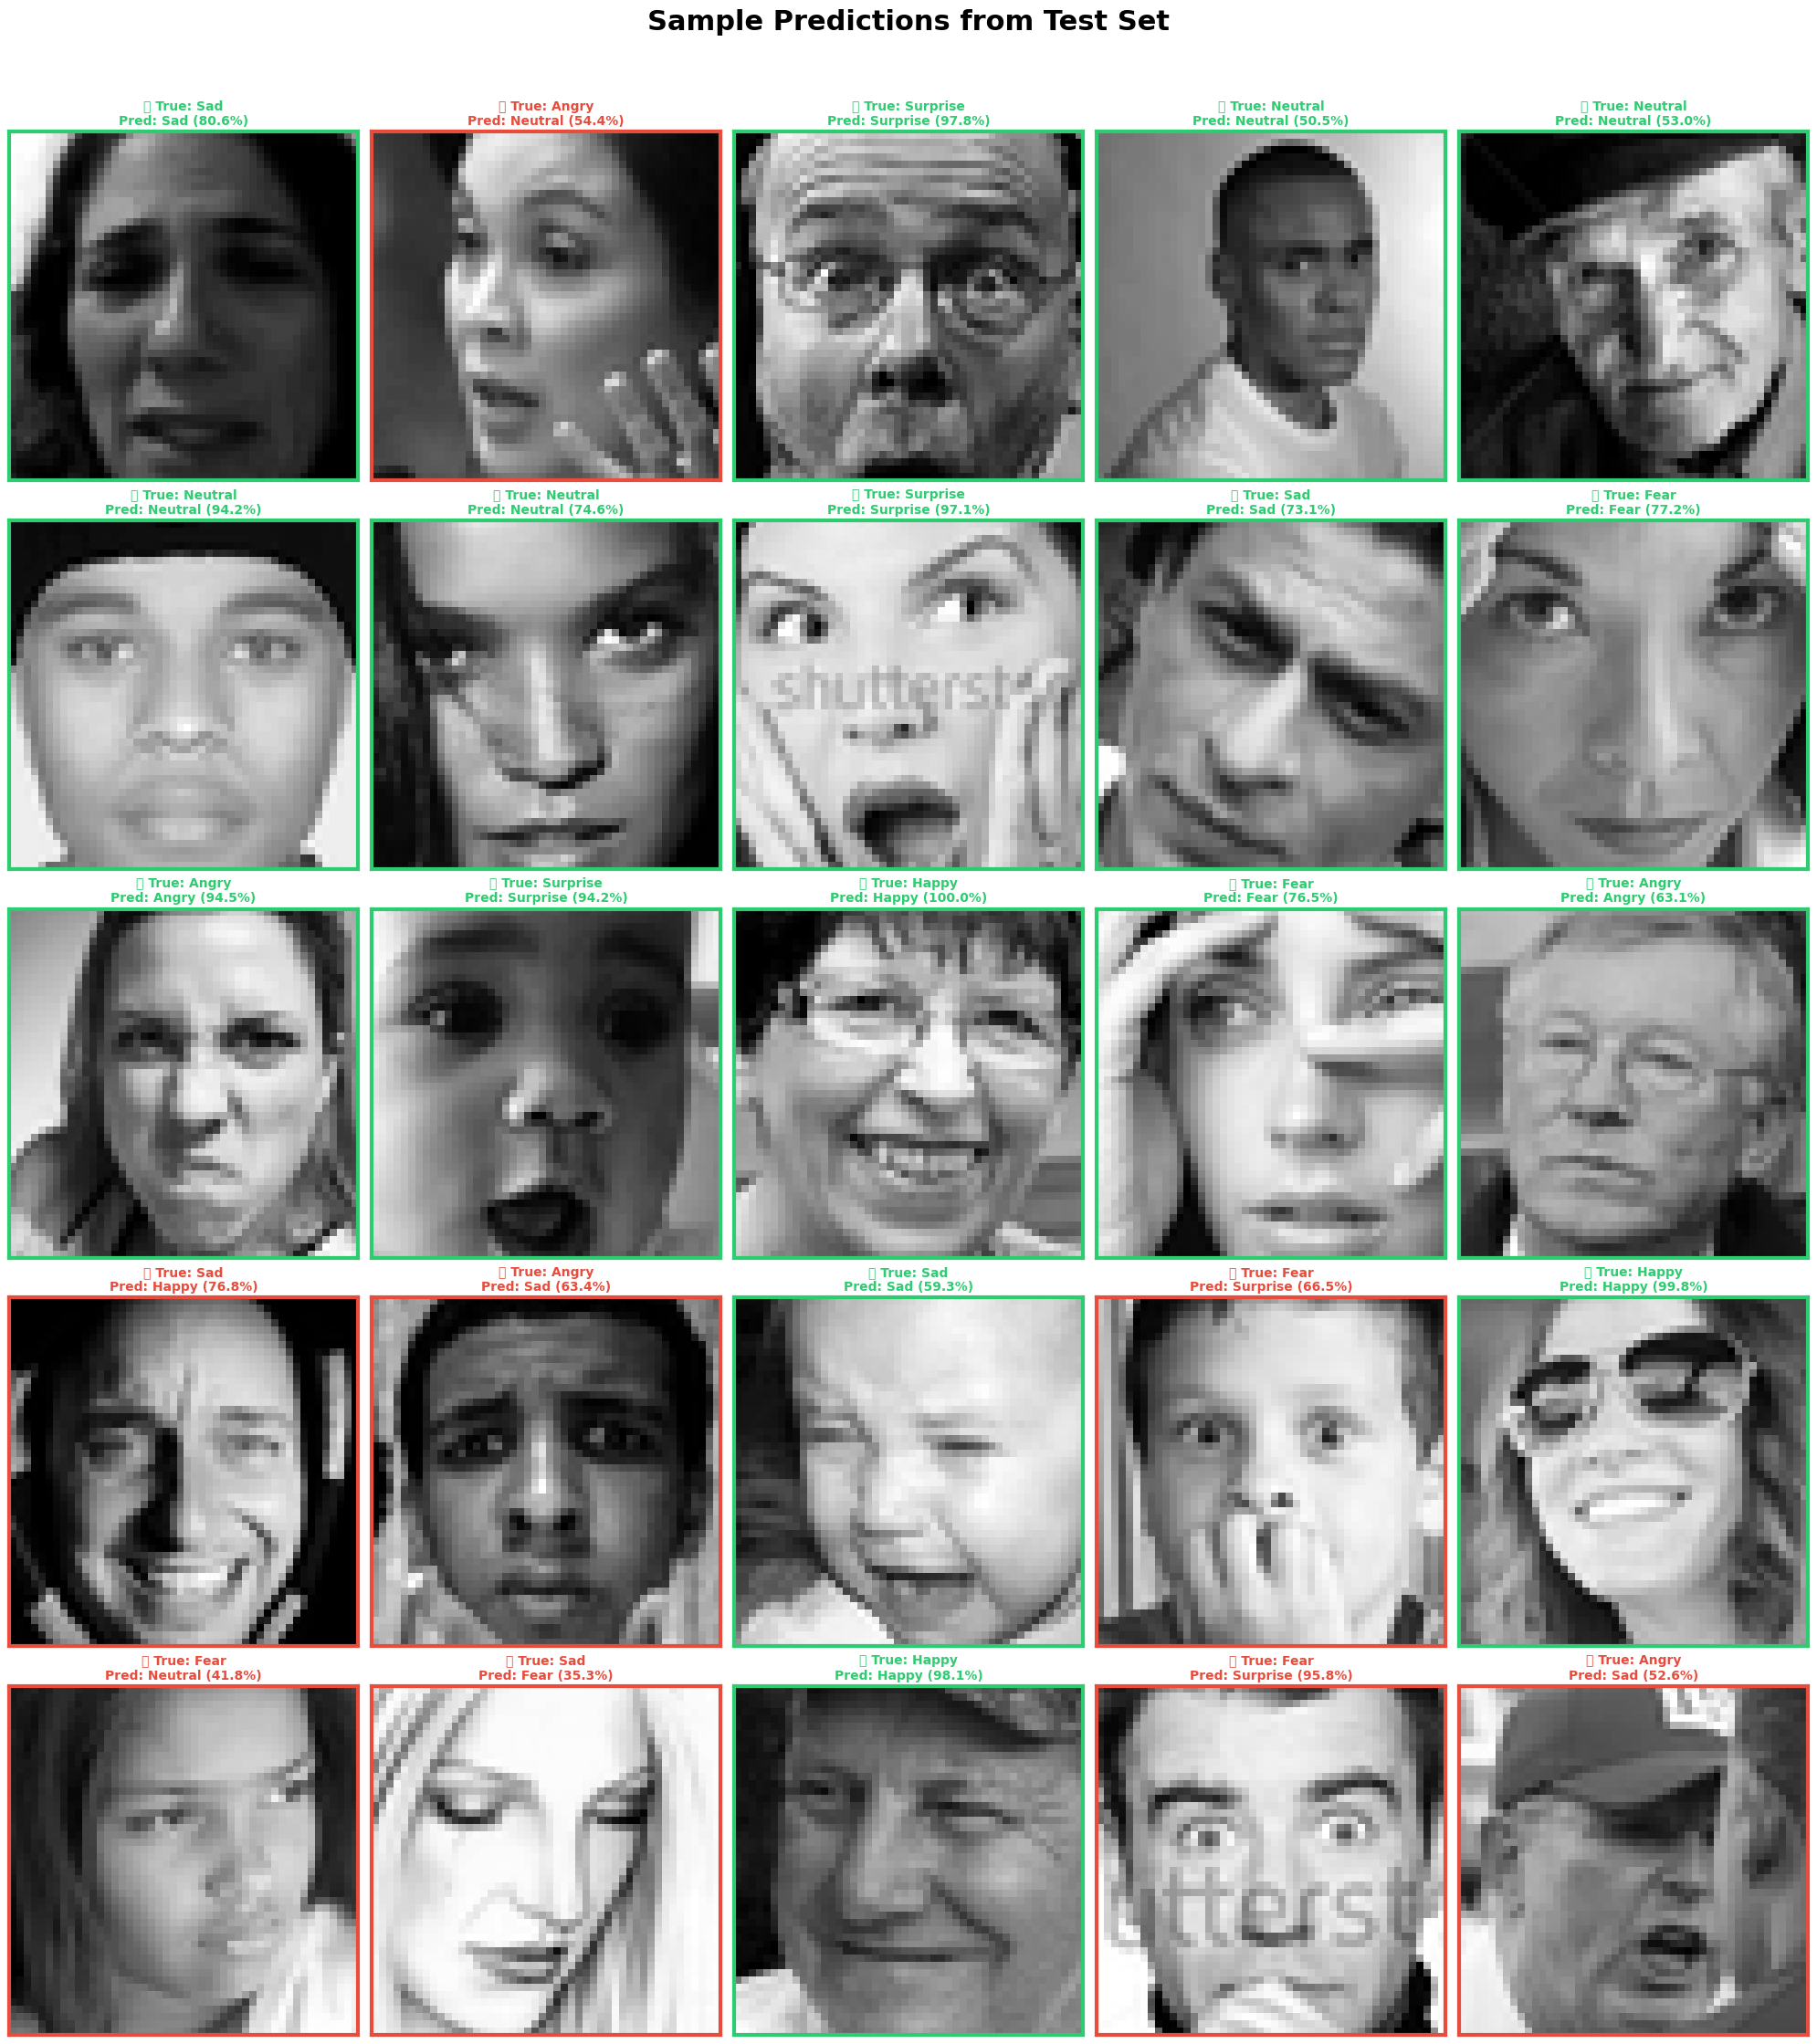


Sample accuracy: 17/25 correct (68%)
Chart saved as sample_predictions_grid.png


In [5]:
# Display 25 random sample predictions in a 5x5 grid
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), size=25, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(20, 22))
fig.suptitle('Sample Predictions from Test Set', fontsize=22, fontweight='bold', y=1.02)

for i, idx in enumerate(sample_indices):
    row, col = i // 5, i % 5
    ax = axes[row, col]
    
    true_label = y_test[idx]
    pred_label = predicted_classes[idx]
    confidence = predicted_confidences[idx] * 100
    is_correct = true_label == pred_label
    
    # Display image
    ax.imshow(X_test_display[idx], cmap='gray')
    
    # Title with true and predicted labels
    title_color = '#2ECC71' if is_correct else '#E74C3C'
    status = '✅' if is_correct else '❌'
    ax.set_title(
        f'{status} True: {EMOTION_LABELS[true_label]}\n'
        f'Pred: {EMOTION_LABELS[pred_label]} ({confidence:.1f}%)',
        fontsize=10, fontweight='bold', color=title_color
    )
    
    # Add colored border
    border_color = '#2ECC71' if is_correct else '#E74C3C'
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig('sample_predictions_grid.png', dpi=150, bbox_inches='tight')
plt.show()

correct_in_sample = sum(1 for idx in sample_indices if predicted_classes[idx] == y_test[idx])
print(f'\nSample accuracy: {correct_in_sample}/25 correct ({correct_in_sample/25*100:.0f}%)')
print('Chart saved as sample_predictions_grid.png')

---
## 6. Detailed Predictions Per Class

Showing **3 sample predictions** from each emotion class.

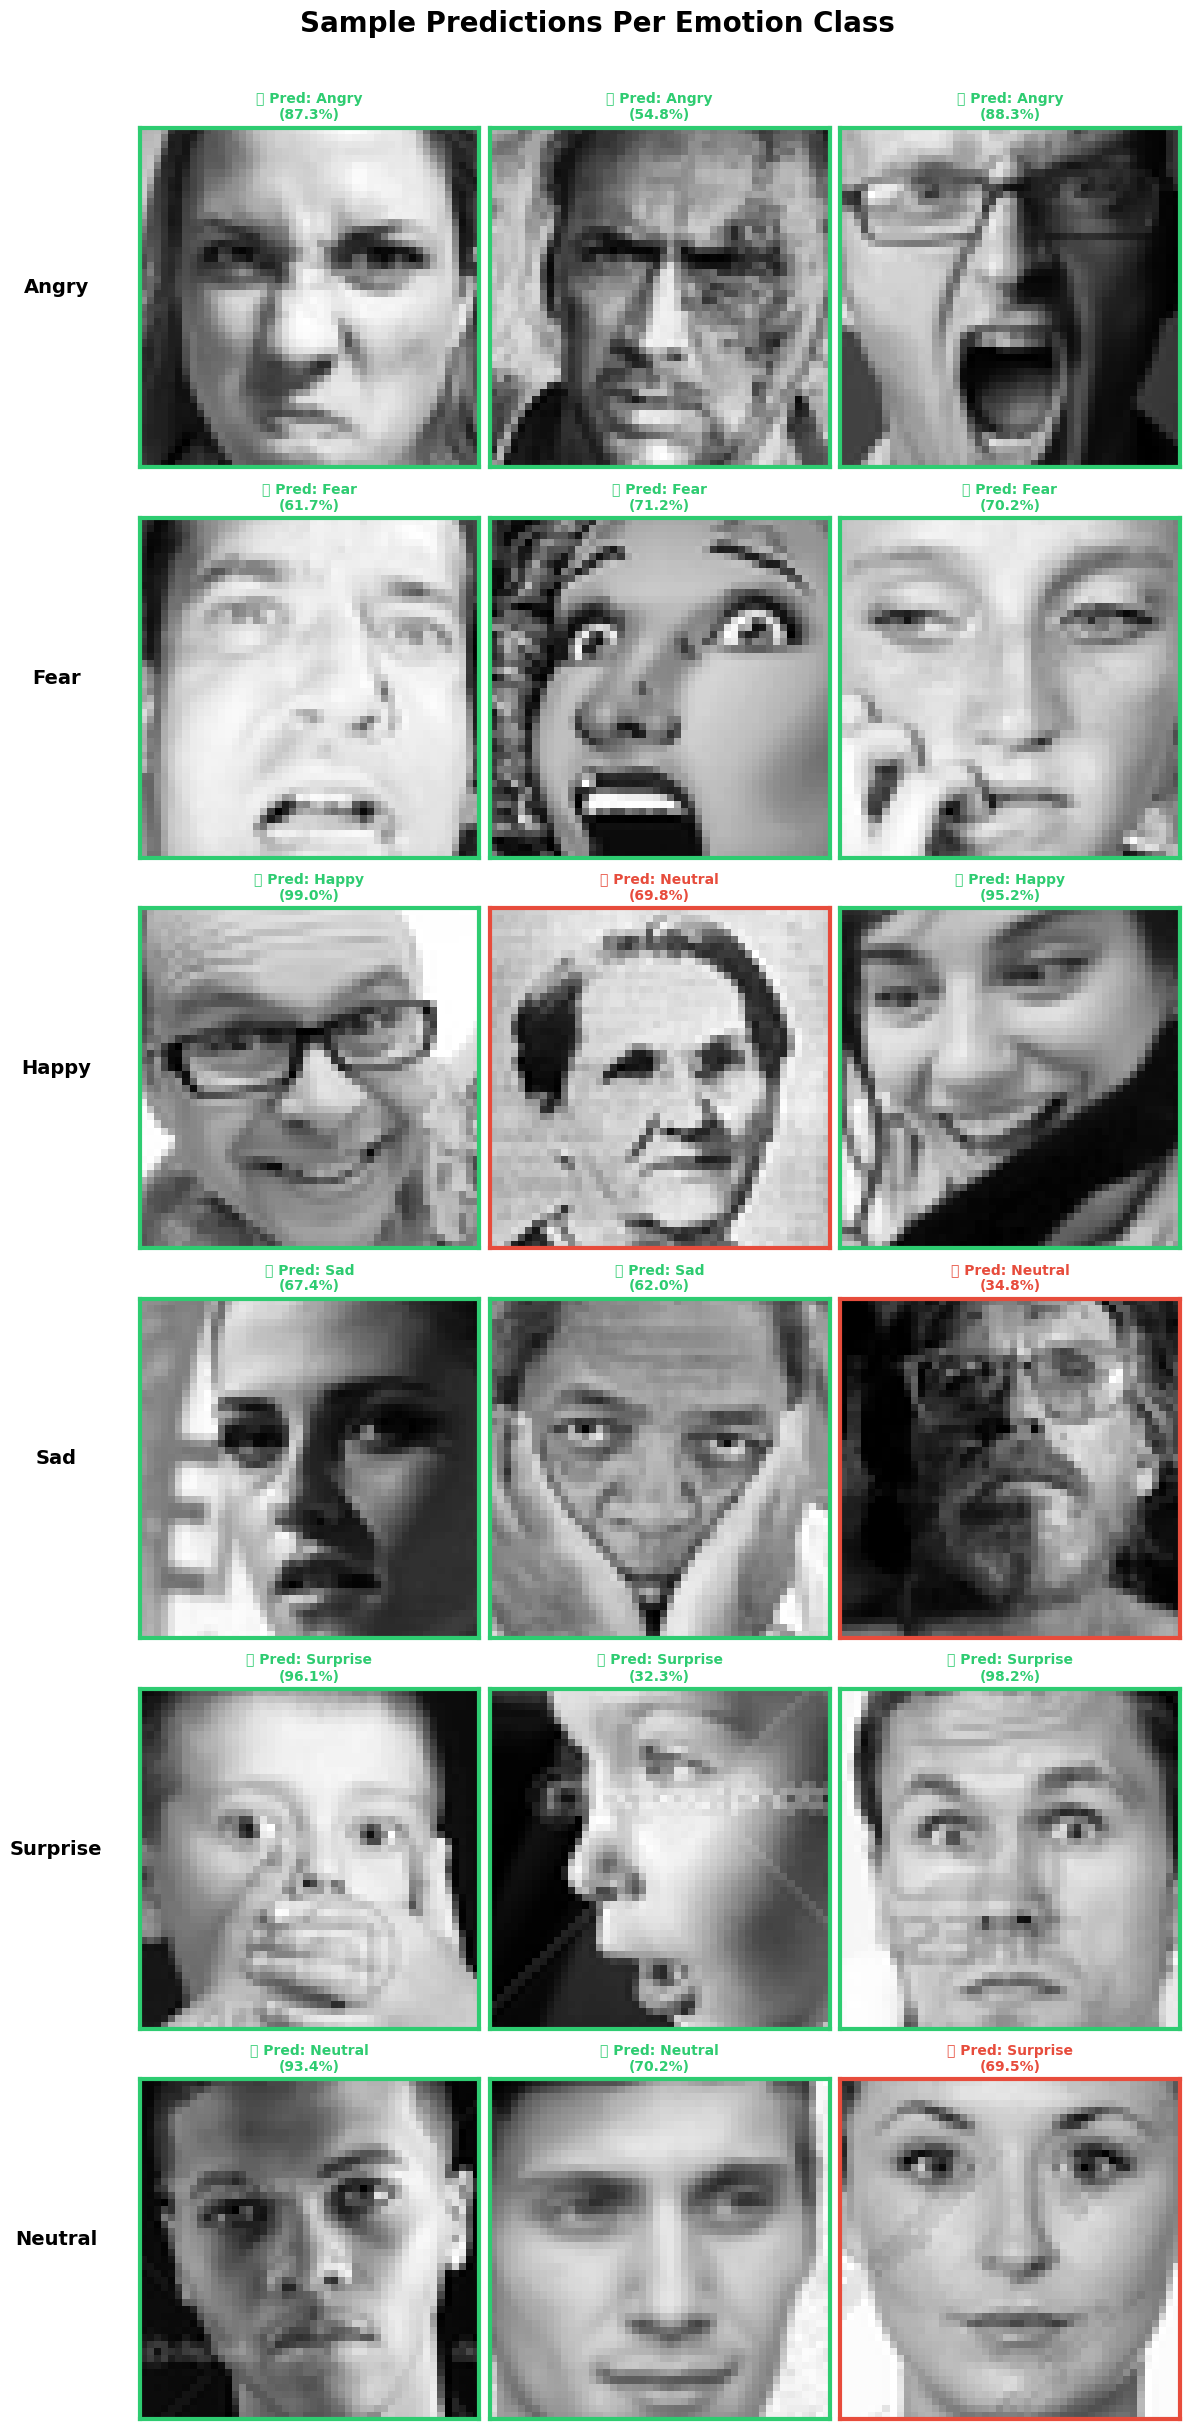

Chart saved as predictions_per_class.png


In [6]:
# Display 3 samples per class
samples_per_class = 3
num_classes = len(EMOTION_LABELS)

fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(12, 24))
fig.suptitle('Sample Predictions Per Emotion Class', fontsize=20, fontweight='bold', y=1.01)

for class_id in range(num_classes):
    # Get indices for this class
    class_indices = np.where(y_test == class_id)[0]
    chosen = np.random.choice(class_indices, size=min(samples_per_class, len(class_indices)), replace=False)
    
    for j, idx in enumerate(chosen):
        ax = axes[class_id, j]
        
        pred_label = predicted_classes[idx]
        confidence = predicted_confidences[idx] * 100
        is_correct = class_id == pred_label
        
        ax.imshow(X_test_display[idx], cmap='gray')
        
        title_color = '#2ECC71' if is_correct else '#E74C3C'
        status = '✅' if is_correct else '❌'
        ax.set_title(
            f'{status} Pred: {EMOTION_LABELS[pred_label]}\n({confidence:.1f}%)',
            fontsize=10, fontweight='bold', color=title_color
        )
        
        for spine in ax.spines.values():
            spine.set_edgecolor(title_color)
            spine.set_linewidth(3)
        ax.set_xticks([])
        ax.set_yticks([])
        
        if j == 0:
            ax.set_ylabel(f'{EMOTION_LABELS[class_id]}', fontsize=14, fontweight='bold', rotation=0, labelpad=60)

plt.tight_layout()
plt.savefig('predictions_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as predictions_per_class.png')

---
## 7. Prediction with Confidence Bar Chart

For selected test images, show the face alongside a horizontal bar chart of confidence scores for all 6 classes.

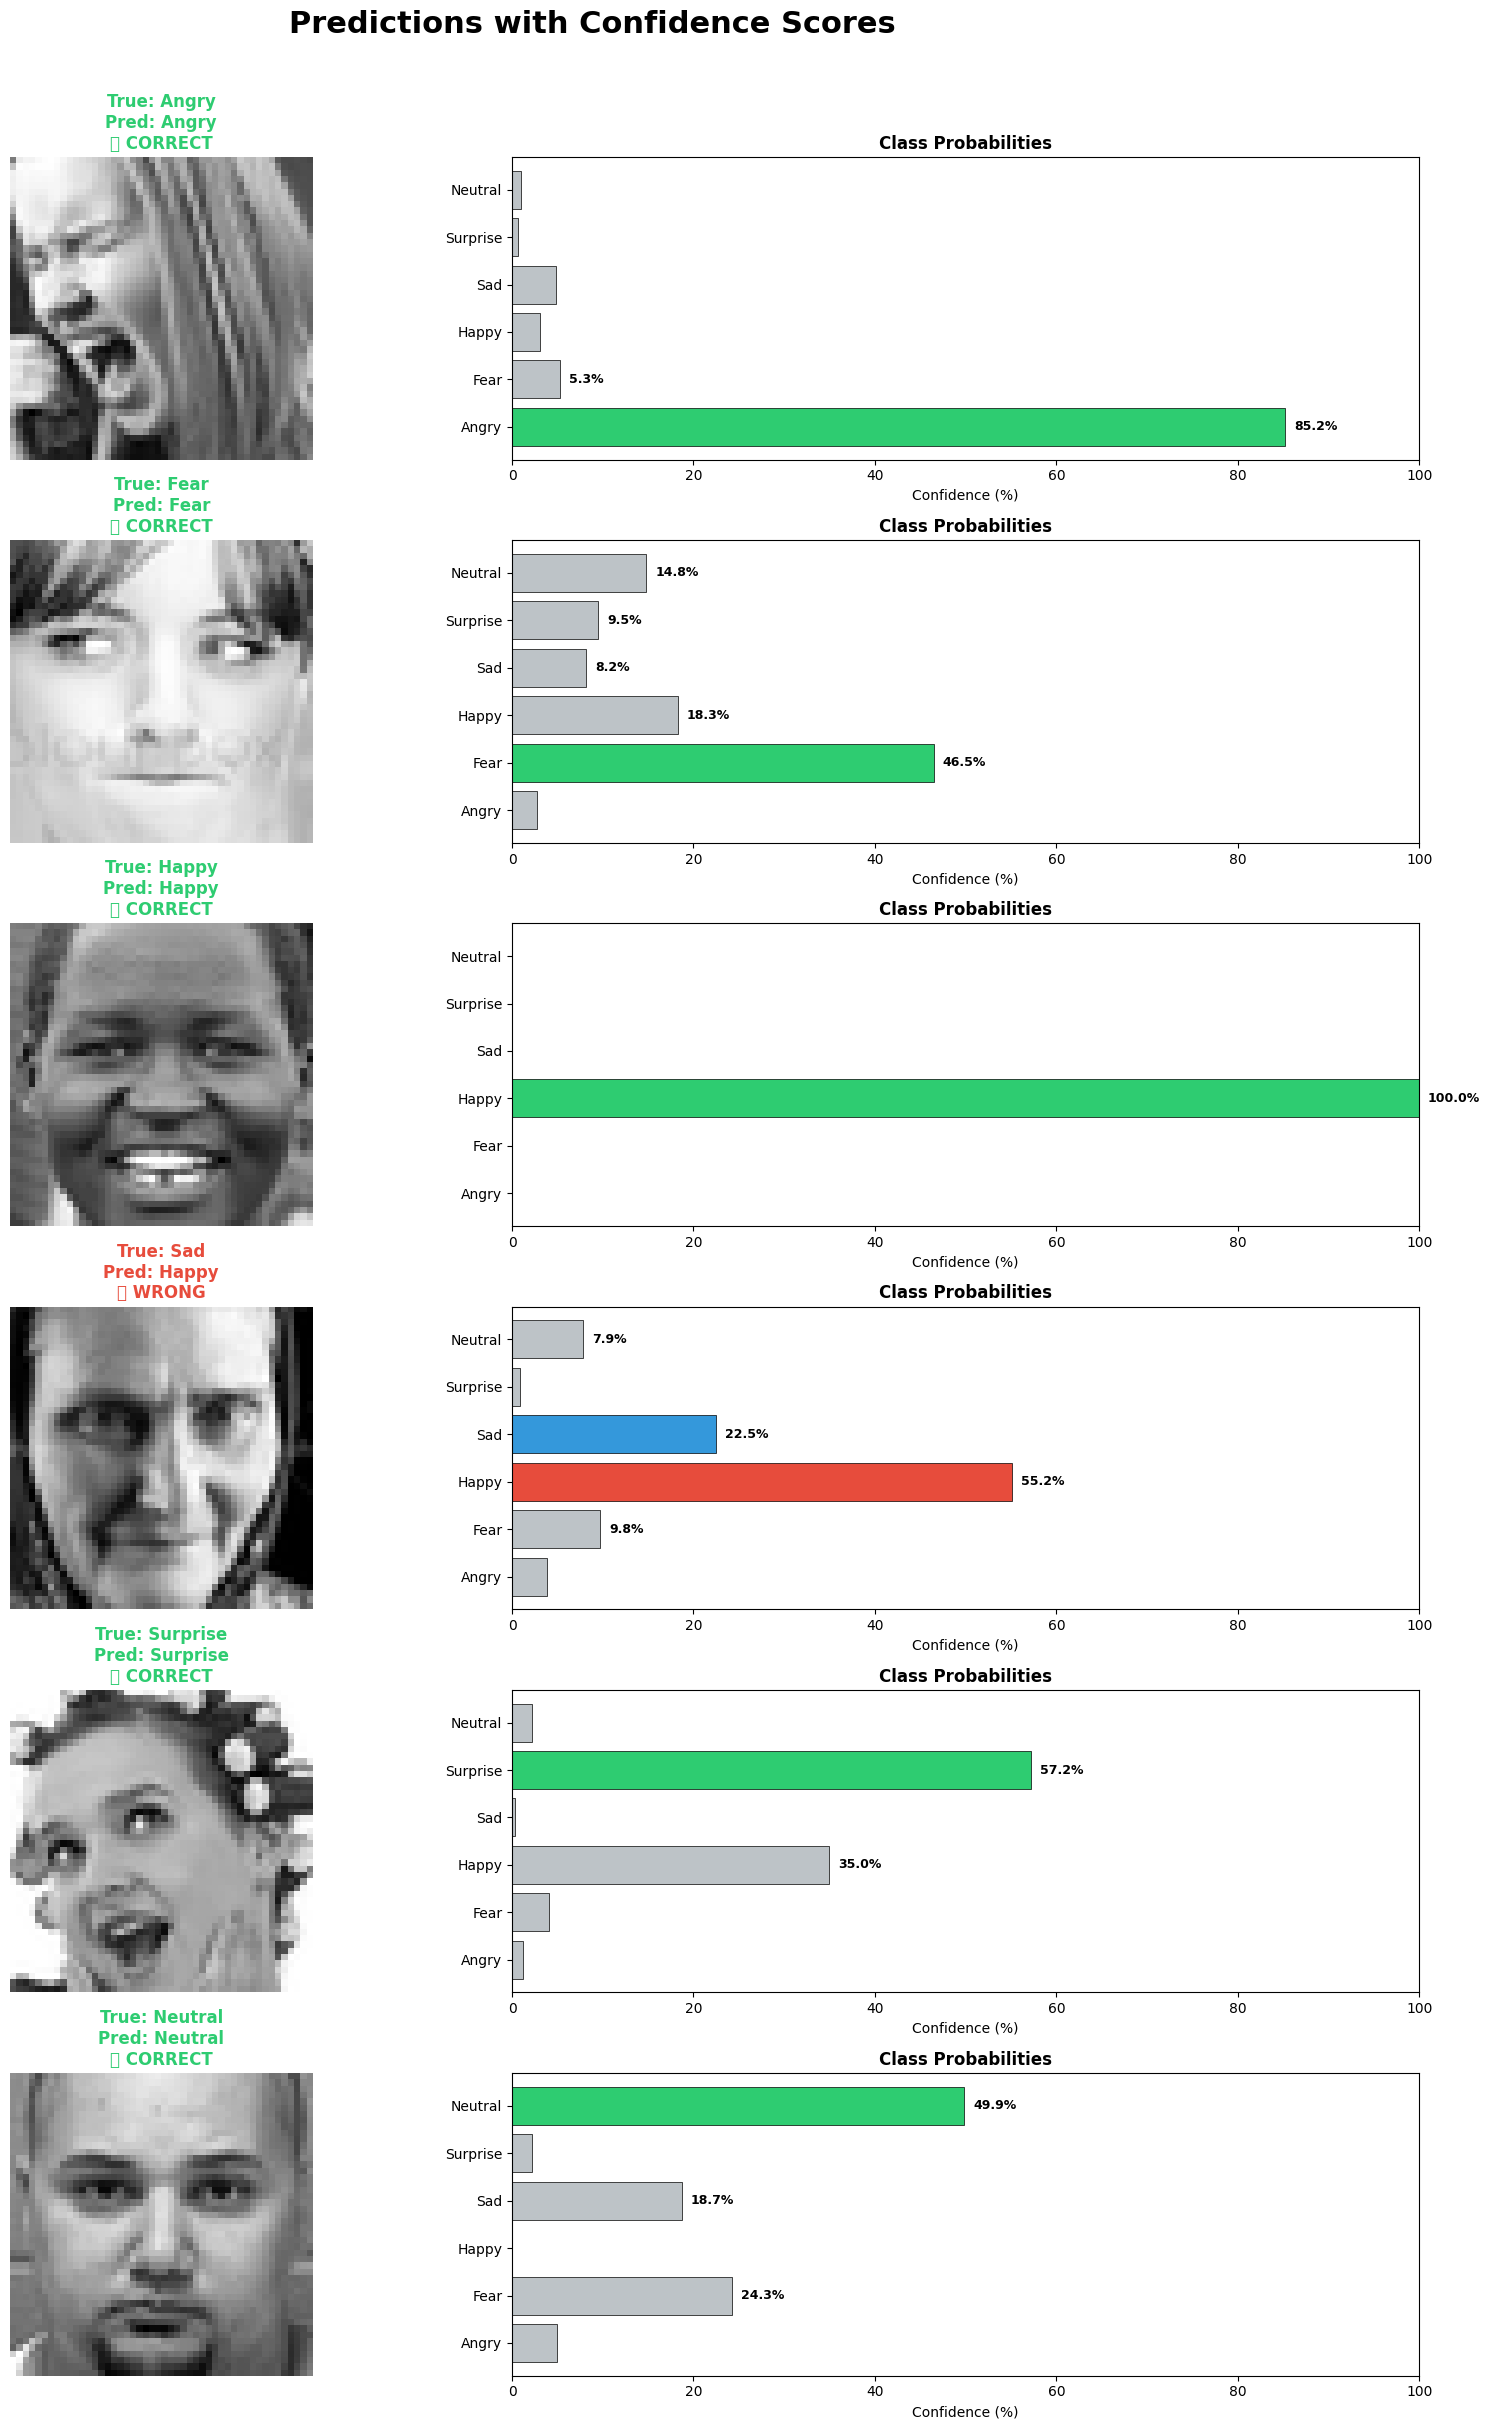

Chart saved as predictions_with_confidence.png


In [7]:
# Display 6 predictions with full confidence bar charts (one per class)
colors_bar = ['#FF6B6B', '#9B59B6', '#FFD93D', '#74B9FF', '#FFA502', '#00D2D3']

fig = plt.figure(figsize=(18, 24))
fig.suptitle('Predictions with Confidence Scores', fontsize=22, fontweight='bold', y=1.01)

# Pick one sample from each true class
for class_id in range(num_classes):
    class_indices = np.where(y_test == class_id)[0]
    idx = np.random.choice(class_indices)
    
    pred_probs = predictions[idx]
    pred_label = predicted_classes[idx]
    is_correct = class_id == pred_label
    
    # Image subplot
    ax_img = fig.add_subplot(num_classes, 2, class_id * 2 + 1)
    ax_img.imshow(X_test_display[idx], cmap='gray')
    status = '✅ CORRECT' if is_correct else '❌ WRONG'
    title_color = '#2ECC71' if is_correct else '#E74C3C'
    ax_img.set_title(
        f'True: {EMOTION_LABELS[class_id]}\nPred: {EMOTION_LABELS[pred_label]}\n{status}',
        fontsize=12, fontweight='bold', color=title_color
    )
    ax_img.axis('off')
    
    # Bar chart subplot
    ax_bar = fig.add_subplot(num_classes, 2, class_id * 2 + 2)
    class_names = [EMOTION_LABELS[i] for i in range(num_classes)]
    bar_colors = []
    for i in range(num_classes):
        if i == pred_label and i == class_id:
            bar_colors.append('#2ECC71')  # Correct prediction - green
        elif i == pred_label:
            bar_colors.append('#E74C3C')  # Wrong prediction - red
        elif i == class_id:
            bar_colors.append('#3498DB')  # True class - blue
        else:
            bar_colors.append('#BDC3C7')  # Other - gray
    
    bars = ax_bar.barh(class_names, pred_probs * 100, color=bar_colors, edgecolor='black', linewidth=0.5)
    ax_bar.set_xlim(0, 100)
    ax_bar.set_xlabel('Confidence (%)', fontsize=10)
    ax_bar.set_title('Class Probabilities', fontsize=12, fontweight='bold')
    
    # Add percentage labels
    for bar, prob in zip(bars, pred_probs):
        if prob > 0.05:
            ax_bar.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                       f'{prob*100:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('predictions_with_confidence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as predictions_with_confidence.png')

---
## 8. Correct vs Incorrect Predictions Showcase

Total correct   : 5446 (77.1%)
Total incorrect : 1622 (22.9%)


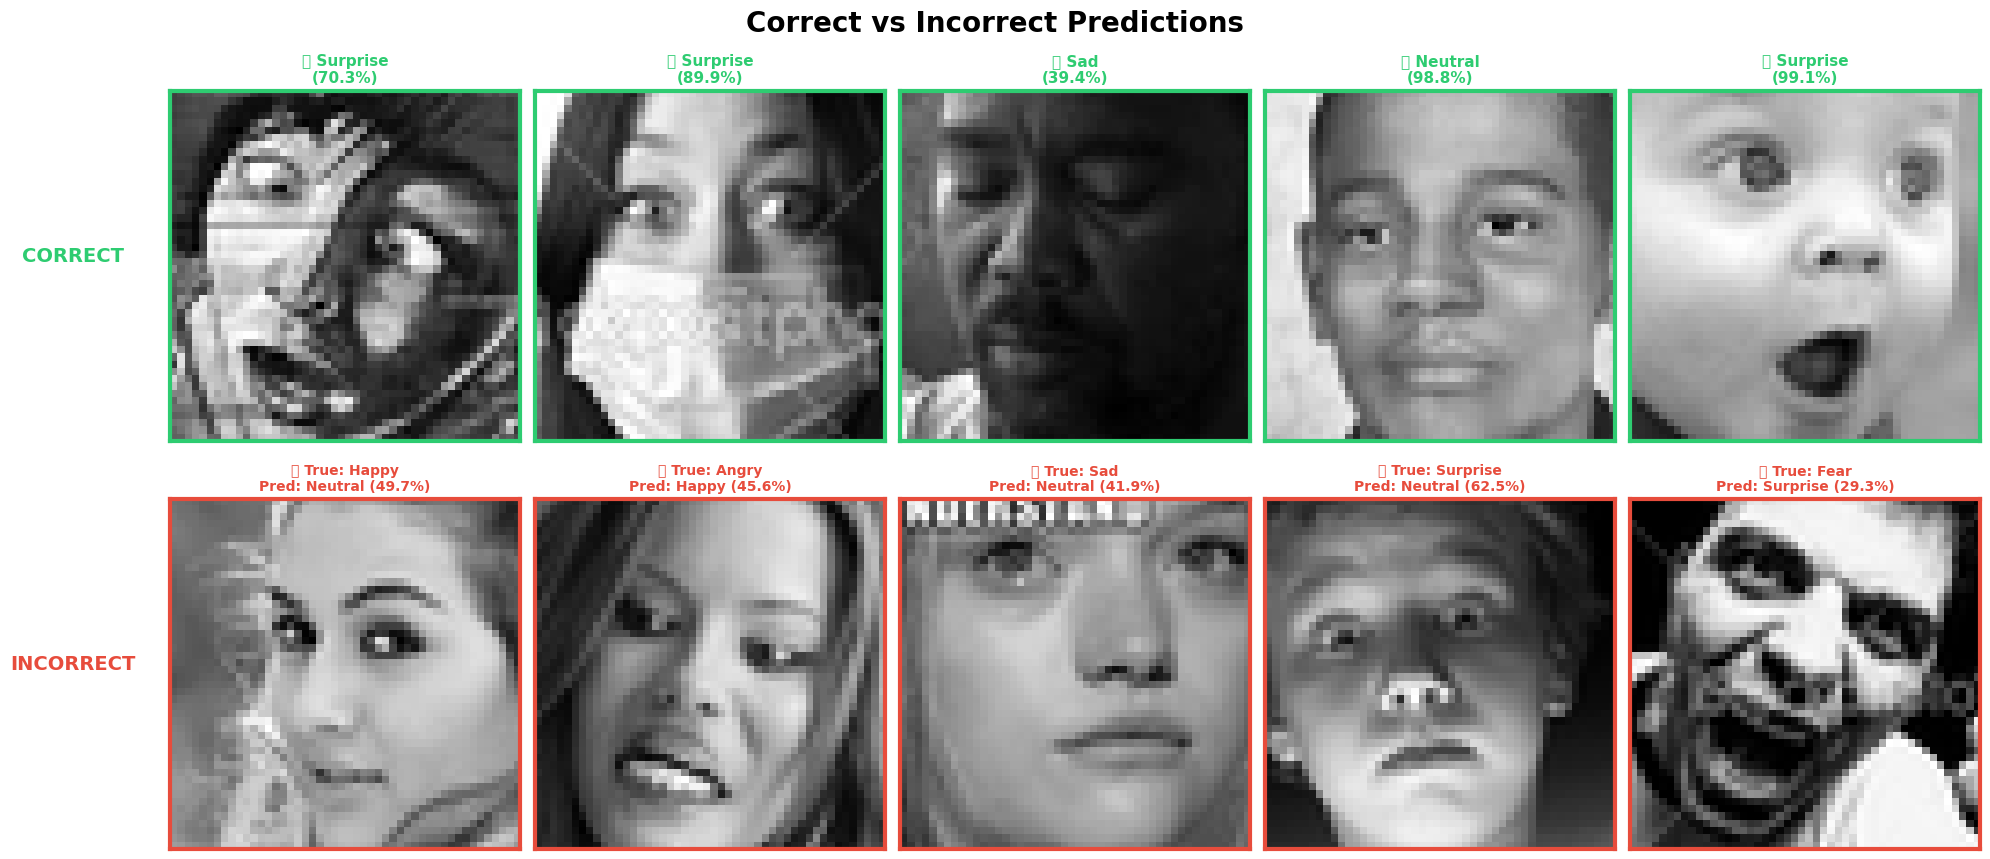

Chart saved as correct_vs_incorrect.png


In [8]:
# Separate correct and incorrect predictions
correct_indices = np.where(predicted_classes == y_test)[0]
incorrect_indices = np.where(predicted_classes != y_test)[0]

print(f'Total correct   : {len(correct_indices)} ({len(correct_indices)/len(y_test)*100:.1f}%)')
print(f'Total incorrect : {len(incorrect_indices)} ({len(incorrect_indices)/len(y_test)*100:.1f}%)')

# Show 5 correct and 5 incorrect predictions side by side
fig, axes = plt.subplots(2, 5, figsize=(20, 9))
fig.suptitle('Correct vs Incorrect Predictions', fontsize=20, fontweight='bold')

# Row 1: Correct predictions
chosen_correct = np.random.choice(correct_indices, size=5, replace=False)
for i, idx in enumerate(chosen_correct):
    ax = axes[0, i]
    ax.imshow(X_test_display[idx], cmap='gray')
    conf = predicted_confidences[idx] * 100
    ax.set_title(
        f'✅ {EMOTION_LABELS[predicted_classes[idx]]}\n({conf:.1f}%)',
        fontsize=11, fontweight='bold', color='#2ECC71'
    )
    for spine in ax.spines.values():
        spine.set_edgecolor('#2ECC71')
        spine.set_linewidth(3)
    ax.set_xticks([])
    ax.set_yticks([])
axes[0, 0].set_ylabel('CORRECT', fontsize=14, fontweight='bold', color='#2ECC71', rotation=0, labelpad=70)

# Row 2: Incorrect predictions
chosen_incorrect = np.random.choice(incorrect_indices, size=5, replace=False)
for i, idx in enumerate(chosen_incorrect):
    ax = axes[1, i]
    ax.imshow(X_test_display[idx], cmap='gray')
    conf = predicted_confidences[idx] * 100
    ax.set_title(
        f'❌ True: {EMOTION_LABELS[y_test[idx]]}\nPred: {EMOTION_LABELS[predicted_classes[idx]]} ({conf:.1f}%)',
        fontsize=10, fontweight='bold', color='#E74C3C'
    )
    for spine in ax.spines.values():
        spine.set_edgecolor('#E74C3C')
        spine.set_linewidth(3)
    ax.set_xticks([])
    ax.set_yticks([])
axes[1, 0].set_ylabel('INCORRECT', fontsize=14, fontweight='bold', color='#E74C3C', rotation=0, labelpad=70)

plt.tight_layout()
plt.savefig('correct_vs_incorrect.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as correct_vs_incorrect.png')

---
## 9. Per-Class Accuracy Summary

In [9]:
# Per-class accuracy
print('=' * 55)
print('PER-CLASS ACCURACY')
print('=' * 55)
print(f'{"Class":<12} {"Total":>7} {"Correct":>9} {"Accuracy":>10}')
print('-' * 55)

class_accuracies = {}
for class_id in range(num_classes):
    mask = y_test == class_id
    total = np.sum(mask)
    correct_count = np.sum(predicted_classes[mask] == class_id)
    acc = correct_count / total * 100 if total > 0 else 0
    class_accuracies[EMOTION_LABELS[class_id]] = acc
    print(f'{EMOTION_LABELS[class_id]:<12} {total:>7} {correct_count:>9} {acc:>9.1f}%')

print('-' * 55)
print(f'{"OVERALL":<12} {len(y_test):>7} {np.sum(predicted_classes == y_test):>9} {accuracy:>9.2f}%')

PER-CLASS ACCURACY
Class          Total   Correct   Accuracy
-------------------------------------------------------
Angry            991       669      67.5%
Fear            1024       535      52.2%
Happy           1798      1696      94.3%
Sad             1215       833      68.6%
Surprise         800       719      89.9%
Neutral         1240       994      80.2%
-------------------------------------------------------
OVERALL         7068      5446     77.05%


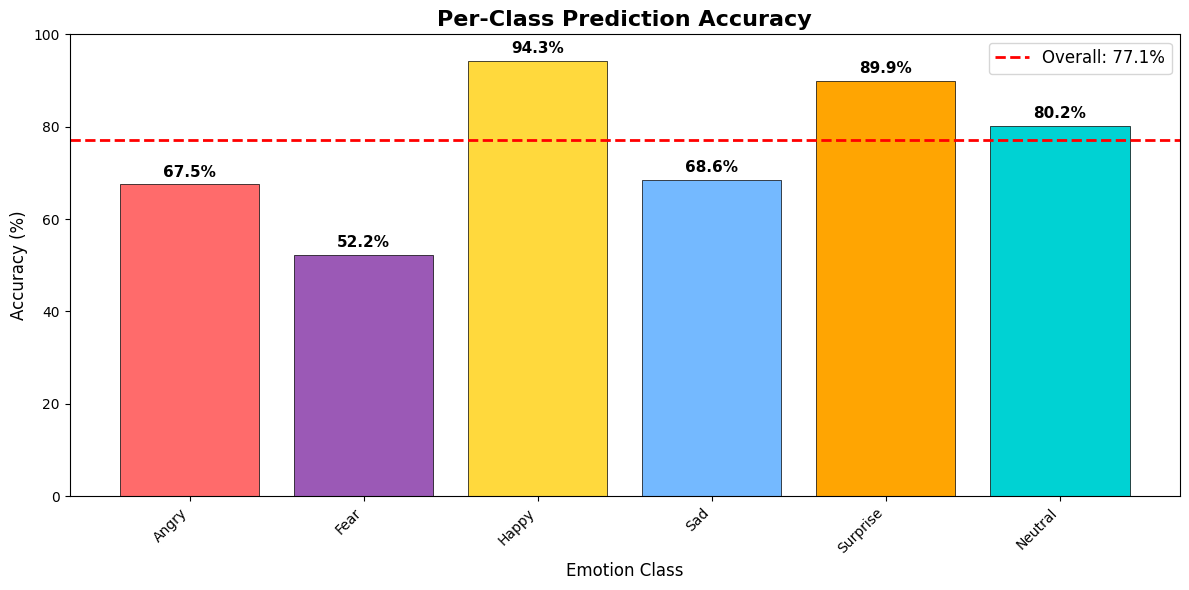

Chart saved as per_class_accuracy.png


In [10]:
# Bar chart of per-class accuracy
colors = ['#FF6B6B', '#9B59B6', '#FFD93D', '#74B9FF', '#FFA502', '#00D2D3']

plt.figure(figsize=(12, 6))
bars = plt.bar(class_accuracies.keys(), class_accuracies.values(), color=colors,
               edgecolor='black', linewidth=0.5)
plt.xlabel('Emotion Class', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Per-Class Prediction Accuracy', fontsize=16, fontweight='bold')
plt.ylim(0, 100)

# Add value labels
for bar, acc in zip(bars, class_accuracies.values()):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Add overall accuracy line
plt.axhline(y=accuracy, color='red', linestyle='--', linewidth=2, label=f'Overall: {accuracy:.1f}%')
plt.legend(fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as per_class_accuracy.png')

---
## 10. Summary

| Item | Details |
|---|---|
| **Model Used** | CNN trained on FER-2013 |
| **Test Set Size** | ~7,068 images |
| **Classes** | Angry, Fear, Happy, Sad, Surprise, Neutral |
| **Visualizations** | Grid predictions, per-class samples, confidence bars, correct vs incorrect |
| **Charts Saved** | `sample_predictions_grid.png`, `predictions_per_class.png`, `predictions_with_confidence.png`, `correct_vs_incorrect.png`, `per_class_accuracy.png` |